In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
import random as rd
from PIL import Image, ImageOps
import copy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
def set_seed(seed=42):
    rd.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(13)

In [4]:
os.environ["HF_HUB_TIMEOUT"] = "300"
os.environ["HF_HUB_READ_TIMEOUT"] = "300"
os.environ["HF_DATASETS_DOWNLOAD_TIMEOUT"] = "300"

In [5]:
from datasets import load_dataset

ds = load_dataset("nf-whoi/whoi-plankton-small")

In [6]:
tmp_img = ds['train'][5]['image']
tmp_img = np.array(tmp_img)
h, w = tmp_img.shape
print(f'Height: {h}, Width: {w}')
for i in range(3):
  h_start = np.random.randint(0, (h-(h*(1/6))))
  w_start = np.random.randint(0, (w-(w*(1/6))))
  tmp_img[h_start:int(h_start+h*(1/5)), w_start:int(w_start+w*(1/5))] = 0
tmp_img

Height: 95, Width: 155


array([[199, 198, 198, ..., 201, 200, 200],
       [193, 197, 195, ..., 204, 201, 200],
       [200, 197, 197, ..., 197, 200, 202],
       ...,
       [199, 194, 197, ..., 199, 200, 202],
       [196, 195, 194, ..., 199, 197, 198],
       [194, 198, 200, ..., 202, 200, 204]], shape=(95, 155), dtype=uint8)

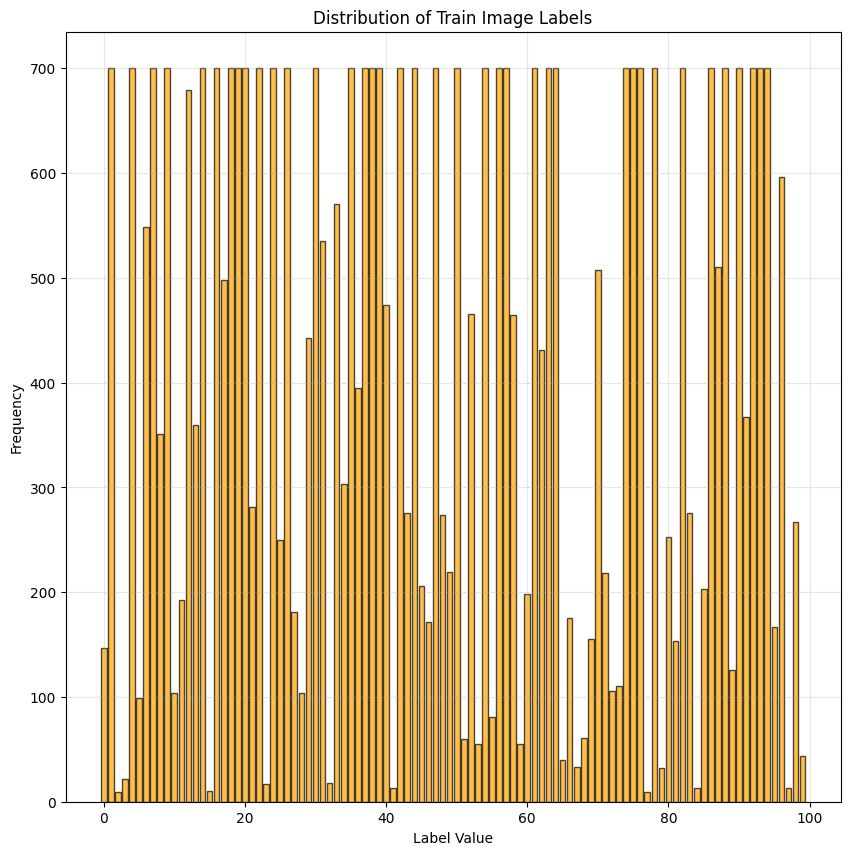

In [7]:
from collections import Counter

plt.figure(figsize=(10, 10))
label_counts = Counter(ds['train'][:]['label'])

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.bar(labels, counts, color='orange', alpha=0.7, edgecolor='black')
plt.xlabel('Label Value')
plt.ylabel('Frequency')
plt.title('Distribution of Train Image Labels')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
weighted_class = [(len(ds['train']) / (100 * label_counts[i])) for i in label_counts]

In [9]:
def salt_pepper(img, prob):
  tmp = np.copy(img)
  matrix = np.random.rand(tmp.shape[0], tmp.shape[1])
  prob = 0.05
  tmp[matrix < prob/2] = 0
  tmp[matrix > 1-prob/2] = 255
  tmp = Image.fromarray(tmp)
  return tmp

In [10]:
train_img = []
size = 64

for data in ds['train']:
    img = np.array(data['image'].convert("L").resize((64, 64)), dtype=np.float32) / 255.0
    label = data['label']
    num_rotate = 3
    num_mask = 3

    if label_counts[label] < 700:
      different = 7000 - (label_counts[label] * 3)
      num_rotate = max(1, int((different / 2)/label_counts[label]))
      num_mask = max(1, int((different / 2)/label_counts[label]))

    for i in range(num_rotate):
      rot_img = np.array(
          data['image'].convert("L").rotate(np.random.randint(180), expand=True).resize((64, 64)),
          dtype=np.float32
      ) / 255.0
      train_img.append({"image": rot_img,  "label": label})

    for i in range(num_mask):
      mask_img = np.array(data['image'].convert("L"), dtype=np.float32)
      h, w = mask_img.shape
      for _ in range(3):
          h_start = np.random.randint(0, int(h - h / 6))
          w_start = np.random.randint(0, int(w - w / 6))
          mask_img[h_start:int(h_start + h/5), w_start:int(w_start + w/5)] = 0
      mask_img = np.array(Image.fromarray(mask_img).resize((64, 64)), dtype=np.float32) / 255.0
      train_img.append({"image": mask_img, "label": label})

    mirror = np.array(ImageOps.mirror(Image.fromarray((img * 255).astype(np.uint8))), dtype=np.float32) / 255.0
    flip   = np.array(ImageOps.flip(Image.fromarray((img * 255).astype(np.uint8))), dtype=np.float32) / 255.0
    sp     = np.array(salt_pepper(img, 0.1), dtype=np.float32)

    train_img.append({"image": img,      "label": label})
    train_img.append({"image": mirror,   "label": label})
    train_img.append({"image": flip,     "label": label})
    train_img.append({"image": sp,       "label": label})

len(train_img)

701910

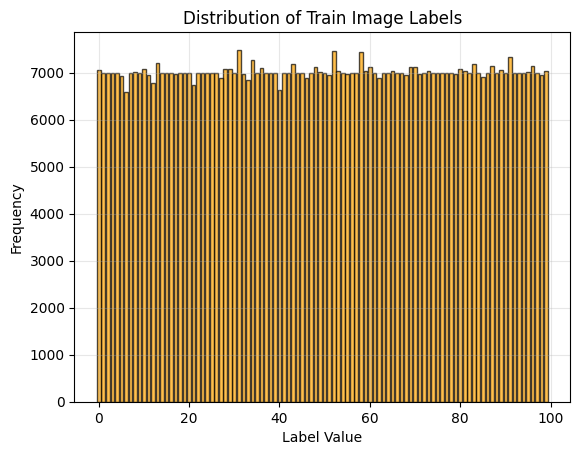

In [11]:
label_counts1 = Counter([data['label'] for data in train_img])

labels = list(label_counts1.keys())
counts = list(label_counts1.values())

plt.bar(labels, counts, color='orange', alpha=0.7, edgecolor='black')
plt.xlabel('Label Value')
plt.ylabel('Frequency')
plt.title('Distribution of Train Image Labels')
plt.grid(True, alpha=0.3)
plt.show()

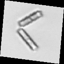

In [12]:
img_show = (train_img[0]['image'] * 255).astype(np.uint8)
img_show = Image.fromarray(img_show)

img_show

In [13]:
#train_img = train_img[:int(len(train_img)*0.5)]

In [14]:
labels = []
for data in train_img:
  label = data['label']
  labels.append(label)

np.unique(labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [15]:
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.proj = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
    self.relu = nn.ReLU()
    self.network = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
    out = self.network(x)
    out = out + self.proj(x)
    return self.relu(out)

In [16]:
class PlanktonCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, 100))
    self.network = nn.Sequential(
            ResBlock(1, 32), nn.MaxPool2d(2),
            ResBlock(32, 64), nn.MaxPool2d(2),
            ResBlock(64, 128), nn.MaxPool2d(2),
            ResBlock(128, 256),
        )

  def forward(self, x):
      out = self.network(x)
      return self.linear(out)

model = PlanktonCNN().to(device)

In [17]:
model1 = PlanktonCNN().to(device)

In [18]:
from torch.utils.data import DataLoader, TensorDataset

data_train_x = []
for data in train_img:
  data_train_x.append(data['image'])
data_train_x = np.array(data_train_x)
data_train_x = torch.tensor(data_train_x, dtype=torch.float32)
print(data_train_x.shape)

data_train_y = []
for data in train_img:
  data_train_y.append(data['label'])
data_train_y = np.array(data_train_y)
data_train_y = torch.tensor(data_train_y, dtype=torch.long)
print(data_train_y.shape)

train_dataset = TensorDataset(data_train_x, data_train_y)

batch_size = 256
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

torch.Size([701910, 64, 64])
torch.Size([701910])


In [19]:
val_img = []

for data in ds['validation']:
  img = data['image'].convert("L").resize((size,size))
  img = np.array(img) / 255.0
  tmp = ({
      "image": img,
      "label": data['label']
  })
  val_img.append(tmp)

len(val_img)

5799

In [20]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weighted_class).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [21]:
val_loss_hist = []
val_acc_hist = []
loss_hist = []
acc_hist = []
log_file = "training2.log"
best_model = copy.deepcopy(model)
best_val_acc = 0

epochs = 200
for epoch in range(epochs):
  running_loss = 0.0
  correct = 0

  model.train()
  for inputs, labels in dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    inputs = inputs.unsqueeze(1)
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    correct += (torch.argmax(probs, dim=1) == labels).sum().item()

  avg_loss = running_loss / len(dataloader)
  accuracy = correct / len(train_img)
  loss_hist.append(avg_loss)
  acc_hist.append(accuracy)

  model.eval()
  correct_val = 0
  val_loss = 0.0
  with torch.no_grad():
    for data in val_img:
      img = torch.tensor(data['image'], dtype=torch.float32)
      label = torch.tensor(data['label'], dtype=torch.long)
      img = img.unsqueeze(0).unsqueeze(0).to(device)
      label = label.unsqueeze(0).to(device)

      outputs = model(img)
      loss = criterion(outputs, label)
      val_loss += loss.item()
      softmax = nn.Softmax(dim=1)
      probs = softmax(outputs)
      predicted_label = torch.argmax(probs, dim=1)
      correct_val += (predicted_label == label).sum().item()
  avg_val_loss = val_loss / len(val_img)
  val_acc = correct_val / len(val_img)
  val_loss_hist.append(avg_val_loss)
  val_acc_hist.append(val_acc)
  if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_model = copy.deepcopy(model)
  log_line = f"Epoch [{epoch+1}/{epochs}] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f} - Val_Loss: {avg_val_loss:.4f} - Val_Acc: {val_acc:.4f}"
  print(log_line)
  with open(log_file, "a") as f:
      f.write(log_line + "\n")

Epoch [1/200] - Average loss: 2.2887 - Accuracy: 0.0845 - Val_Loss: 3.4657 - Val_Acc: 0.1562
Epoch [2/200] - Average loss: 1.4818 - Accuracy: 0.2072 - Val_Loss: 2.8417 - Val_Acc: 0.2675
Epoch [3/200] - Average loss: 1.1758 - Accuracy: 0.3171 - Val_Loss: 2.4739 - Val_Acc: 0.3332
Epoch [4/200] - Average loss: 0.9974 - Accuracy: 0.3963 - Val_Loss: 1.9327 - Val_Acc: 0.4409
Epoch [5/200] - Average loss: 0.8701 - Accuracy: 0.4561 - Val_Loss: 1.7086 - Val_Acc: 0.5027
Epoch [6/200] - Average loss: 0.7736 - Accuracy: 0.5042 - Val_Loss: 1.5825 - Val_Acc: 0.5342
Epoch [7/200] - Average loss: 0.6967 - Accuracy: 0.5434 - Val_Loss: 1.5709 - Val_Acc: 0.5403
Epoch [8/200] - Average loss: 0.6343 - Accuracy: 0.5763 - Val_Loss: 1.4114 - Val_Acc: 0.5932
Epoch [9/200] - Average loss: 0.5807 - Accuracy: 0.6026 - Val_Loss: 1.3943 - Val_Acc: 0.6015
Epoch [10/200] - Average loss: 0.5335 - Accuracy: 0.6257 - Val_Loss: 1.4610 - Val_Acc: 0.5885
Epoch [11/200] - Average loss: 0.4950 - Accuracy: 0.6457 - Val_Loss: 

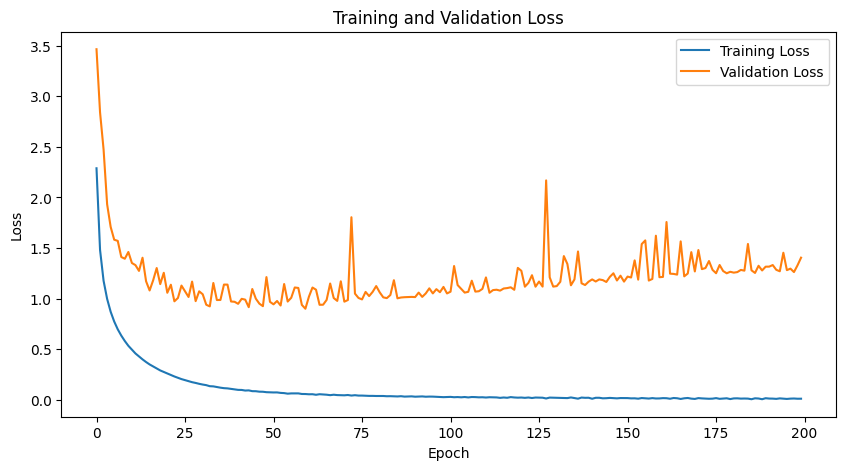

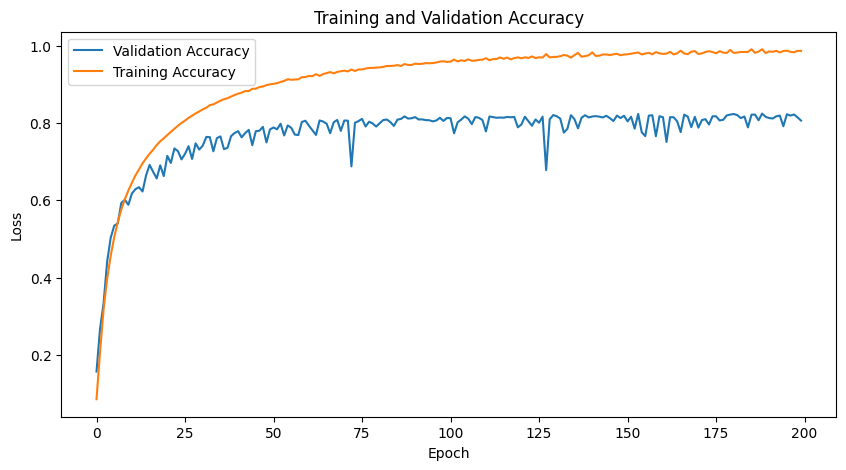

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(loss_hist, label='Training Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("loss_curve2.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_acc_hist, label='Validation Accuracy')
plt.plot(acc_hist, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.savefig("accuracy_curve2.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
"""criterion1 = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=1e-4)"""

'criterion1 = nn.CrossEntropyLoss()\noptimizer1 = optim.Adam(model1.parameters(), lr=1e-4)'

In [24]:
"""set_seed(12)
for epoch in range(epochs):
  running_loss = 0.0
  correct = 0

  model1.train()
  for inputs, labels in dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    inputs = inputs.unsqueeze(1)
    optimizer1.zero_grad()

    outputs = model1(inputs)
    loss = criterion1(outputs, labels)
    loss.backward()
    optimizer1.step()
    running_loss += loss.item()

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    correct += (torch.argmax(probs, dim=1) == labels).sum().item()

  avg_loss = running_loss / len(dataloader)
  accuracy = correct / len(train_img)
  print(f'Epoch [{epoch+1}/100] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}')"""

"set_seed(12)\nfor epoch in range(epochs):\n  running_loss = 0.0\n  correct = 0\n\n  model1.train()\n  for inputs, labels in dataloader:\n    inputs = inputs.to(device)\n    labels = labels.to(device)\n    inputs = inputs.unsqueeze(1)\n    optimizer1.zero_grad()\n\n    outputs = model1(inputs)\n    loss = criterion1(outputs, labels)\n    loss.backward()\n    optimizer1.step()\n    running_loss += loss.item()\n\n    softmax = nn.Softmax(dim=1)\n    probs = softmax(outputs)\n    correct += (torch.argmax(probs, dim=1) == labels).sum().item()\n\n  avg_loss = running_loss / len(dataloader)\n  accuracy = correct / len(train_img)\n  print(f'Epoch [{epoch+1}/100] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}')"

In [25]:
"""class Co_CNN(nn.Module):
  def __init__(self, model, model1):
    super().__init__()
    for param in model.network.parameters():
      param.requires_grad = False

    for param in model1.network.parameters():
      param.requires_grad = False

    self.backbone1 = nn.Sequential(*list(model.network.children())[:-1])
    self.backbone2 = nn.Sequential(*list(model1.network.children())[:-1])
    self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 100))

  def forward(self, x):
        f1 = self.backbone1(x)
        f2 = self.backbone2(x)

        f1 = f1.flatten(1)
        f2 = f2.flatten(1)

        f = torch.cat([f1, f2], dim=1)
        out = self.classifier(f)
        return out

co_model = Co_CNN(model, model1).to(device)"""

'class Co_CNN(nn.Module):\n  def __init__(self, model, model1):\n    super().__init__()\n    for param in model.network.parameters():\n      param.requires_grad = False\n\n    for param in model1.network.parameters():\n      param.requires_grad = False\n\n    self.backbone1 = nn.Sequential(*list(model.network.children())[:-1])\n    self.backbone2 = nn.Sequential(*list(model1.network.children())[:-1])\n    self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 100))\n\n  def forward(self, x):\n        f1 = self.backbone1(x)\n        f2 = self.backbone2(x)\n\n        f1 = f1.flatten(1)\n        f2 = f2.flatten(1)\n\n        f = torch.cat([f1, f2], dim=1)\n        out = self.classifier(f)\n        return out\n\nco_model = Co_CNN(model, model1).to(device)'

In [26]:
"""criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(co_model.parameters(), lr=1e-4)"""

'criterion2 = nn.CrossEntropyLoss()\noptimizer2 = optim.Adam(co_model.parameters(), lr=1e-4)'

In [27]:
"""set_seed(11)
for epoch in range(epochs):
  running_loss = 0.0
  correct = 0

  co_model.train()
  for inputs, labels in dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    inputs = inputs.unsqueeze(1)
    optimizer2.zero_grad()

    outputs = co_model(inputs)
    loss = criterion2(outputs, labels)
    loss.backward()
    optimizer2.step()
    running_loss += loss.item()

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    correct += (torch.argmax(probs, dim=1) == labels).sum().item()

  avg_loss = running_loss / len(dataloader)
  accuracy = correct / len(train_img)
  print(f'Epoch [{epoch+1}/100] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}')"""

"set_seed(11)\nfor epoch in range(epochs):\n  running_loss = 0.0\n  correct = 0\n\n  co_model.train()\n  for inputs, labels in dataloader:\n    inputs = inputs.to(device)\n    labels = labels.to(device)\n    inputs = inputs.unsqueeze(1)\n    optimizer2.zero_grad()\n\n    outputs = co_model(inputs)\n    loss = criterion2(outputs, labels)\n    loss.backward()\n    optimizer2.step()\n    running_loss += loss.item()\n\n    softmax = nn.Softmax(dim=1)\n    probs = softmax(outputs)\n    correct += (torch.argmax(probs, dim=1) == labels).sum().item()\n\n  avg_loss = running_loss / len(dataloader)\n  accuracy = correct / len(train_img)\n  print(f'Epoch [{epoch+1}/100] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}')"

In [28]:
for param in model.network.parameters():
  param.requires_grad = True

for param in model1.network.parameters():
  param.requires_grad = True

In [29]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable: {trainable:,}")
print(f"Frozen: {total-trainable:,}")

Total params: 1,243,780
Trainable: 1,243,780
Frozen: 0


In [30]:
test_img = []

for data in ds['test']:
  img = data['image'].convert("L").resize((size,size))
  img = np.array(img) / 255.0
  tmp = ({
      "image": img,
      "label": data['label']
  })
  test_img.append(tmp)

len(test_img)

11601

In [31]:
model.eval()
with torch.no_grad():
  correct = 0
  total_samples = 0
  for data in test_img:
    img = torch.tensor(data['image'], dtype=torch.float32)
    label = torch.tensor(data['label'], dtype=torch.long)

    img = img.unsqueeze(0).unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)

    outputs = best_model(img)

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    predicted_label = torch.argmax(probs, dim=1)
    correct += (predicted_label == label).sum().item()
    total_samples += 1

  accuracy = correct / total_samples
  test_acc = f'Accuracy: {accuracy:.4f}'
  print(f'Accuracy: {accuracy:.4f}')
  with open(log_file, "a") as f:
      f.write(test_acc + "\n")

Accuracy: 0.8254


In [32]:
model.eval()
with torch.no_grad():
  correct = 0
  total_samples = 0
  for data in val_img:
    img = torch.tensor(data['image'], dtype=torch.float32)
    label = torch.tensor(data['label'], dtype=torch.long)

    img = img.unsqueeze(0).unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)

    outputs = best_model(img)

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    predicted_label = torch.argmax(probs, dim=1)
    correct += (predicted_label == label).sum().item()
    total_samples += 1

  accuracy = correct / total_samples
  print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8250


In [33]:
model.eval()
sample_x = data_train_x[:1].unsqueeze(1).to(device)
sample_y = data_train_y[:1].to(device)

with torch.no_grad():
    out = model(sample_x)
    print("Output shape:", out.shape)
    print("Output sample (logits):", out[0][:10])
    print("Max logit:", out.max().item())
    print("Min logit:", out.min().item())

    loss = criterion(out, sample_y)
    print("Manual loss:", loss.item())

Output shape: torch.Size([1, 100])
Output sample (logits): tensor([ -7.3667,  -0.1662, -57.0828, -24.7089, -18.2487, -22.6749, -17.7864,
         -3.7394,  -2.0236, -24.3199], device='cuda:0')
Max logit: 21.73446273803711
Min logit: -63.55704879760742
Manual loss: 2.3841855067985307e-07


In [34]:
softmax = nn.Softmax(dim=1)
probs = softmax(out)
print(torch.argmax(probs, dim=1))

tensor([74], device='cuda:0')


In [35]:
model.train()
sample_x = data_train_x[:8].unsqueeze(1).to(device)
sample_y = data_train_y[:8].to(device)

optimizer.zero_grad()
out = model(sample_x)
loss = criterion(out, sample_y)
loss.backward()

for name, param in model1.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad_mean={param.grad.abs().mean():.6f}, grad_max={param.grad.abs().max():.6f}")

In [36]:
example_inputs = (torch.randn(1, 1, 64, 64).to(device))
onnx_program = torch.onnx.export(best_model, example_inputs, dynamo=True)
onnx_program.save("plankton_classifier_model.onnx")

[torch.onnx] Obtain model graph for `PlanktonCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PlanktonCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 12 of general pattern rewrite rules.


/venv/main/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
